In [1]:
import os
import pandas as pd

<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


In [71]:
directory = "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/single_zoning_experiment"

# List all directories
directories = [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]

# Initialize an empty DataFrame
df_list = []


# Iterate over each directory
for d in directories:
    progress_file = os.path.join(directory, d, "progress.csv")
    if os.path.isfile(progress_file):
        # Read the progress.csv file into a DataFrame
        df = pd.read_csv(progress_file)
        # Add a column for directory name
        df['Directory'] = d.split("Eplus-env-06-12_thermostat_rbc_eco_case_0_rep_0_")[-1]
        # Append the DataFrame to the list
        df_list.append(df)

# Concatenate all DataFrames in the list
result_df = pd.concat(df_list, ignore_index=True)

# Drop rows with NaN values only in the "cumulative_reward" column
result_df = result_df.dropna(subset=['cumulative_reward'])

# Assuming df is your DataFrame
df_sorted = result_df.sort_values(by='Directory')

zones = ["hall_downstairs",
        "front_room",
        "kitchen",
        "backroom",
        "bedroom_3",
        "bedroom_1",
        "hall_upstairs",
        "bathroom",
        "bedroom_2",
        "none"]

df_sorted["zones"] = zones



In [74]:
df_sorted = df_sorted.set_index("zones")

In [75]:
df_sorted

,episode_num,cost,gas_cost,electricity_cost,cumulative_reward,mean_reward,cumulative_emissions,mean_emissions,cumulative_comfort_penalty,mean_comfort_penalty,...,comfort_violation (%),mean_comfort_violation,std_comfort_violation,cumulative_comfort_violation,mean_air_quality_violation,std_air_quality_violation,cumulative_air_quality_violation,length(timesteps),time_elapsed(seconds),Directory
zones,,,,,,,,,,,,,,,,,,,,,
hall_downstairs,0,161989.522478,161989.522478,0.0,-517494.897608,-9.845793,3380.049785,0.064308,-397.584161,-0.007564,...,8.670091,0.007564,0.074836,3.845737e+07,731.685093,786.653853,397.584161,52560,31536000,iter_0_zoning_influence_test_manual-res1
front_room,0,161389.759131,161389.759131,0.0,-518846.260468,-9.871504,3367.119750,0.064062,-415.522935,-0.007906,...,8.913623,0.007906,0.075973,3.863978e+07,735.155585,791.568782,415.522935,52560,31536000,iter_1_zoning_influence_test_manual-res1
kitchen,0,161961.026310,161961.026310,0.0,-516541.666366,-9.827657,3379.664533,0.064301,-402.780834,-0.007663,...,8.632040,0.007663,0.075308,3.836386e+07,729.905955,785.579434,402.780834,52560,31536000,iter_2_zoning_influence_test_manual-res1
backroom,0,161417.984462,161417.984462,0.0,-519076.148242,-9.875878,3367.152905,0.064063,-413.108442,-0.007860,...,8.786149,0.007860,0.075816,3.866070e+07,735.553628,791.525071,413.108442,52560,31536000,iter_3_zoning_influence_test_manual-res1
bedroom_3,0,161079.526672,161079.526672,0.0,-518544.887257,-9.865770,3360.357189,0.063934,-443.912255,-0.008446,...,8.531202,0.008446,0.082842,3.863218e+07,735.011062,791.598403,443.912255,52560,31536000,iter_4_zoning_influence_test_manual-res1
bedroom_1,0,159546.991674,159546.991674,0.0,-515742.817418,-9.812458,3327.586566,0.063310,-453.994997,-0.008638,...,8.999239,0.008638,0.081883,3.847634e+07,732.046097,789.561090,453.994997,52560,31536000,iter_5_zoning_influence_test_manual-res1
hall_upstairs,0,162078.596111,162078.596111,0.0,-515726.828322,-9.812154,3383.455121,0.064373,-470.000355,-0.008942,...,8.407534,0.008942,0.085626,3.826603e+07,728.044765,784.786437,470.000355,52560,31536000,iter_6_zoning_influence_test_manual-res1
bathroom,0,161685.570305,161685.570305,0.0,-518783.817228,-9.870316,3372.809272,0.064171,-455.389164,-0.008664,...,8.573059,0.008664,0.083282,3.860535e+07,734.500500,791.981029,455.389164,52560,31536000,iter_7_zoning_influence_test_manual-res1
bedroom_2,0,161417.714133,161417.714133,0.0,-518477.919496,-9.864496,3367.141743,0.064063,-447.996983,-0.008524,...,8.696728,0.008524,0.081551,3.859741e+07,734.349487,791.259214,447.996983,52560,31536000,iter_8_zoning_influence_test_manual-res1


In [42]:
schedule = pd.read_csv("/workspaces/CUBES/cubes/data/schedules/thermostat_exp/rep0/schedule_rep_0.sch")


In [84]:
# Step 1: Convert 'Unnamed: 0' to datetime format
schedule['Unnamed: 0'] = pd.to_datetime(schedule['Unnamed: 0'], format='%d/%m/%Y %H:%M')

# Step 2: Filter rows outside of 23:00 to 06:00
filtered_df = schedule[(schedule['Unnamed: 0'].dt.hour < 23) | (schedule['Unnamed: 0'].dt.hour >= 6)]

# Step 3: Calculate occupancy percentage for each zone
total_intervals = len(filtered_df)
occupancy_percentages = {}

# Iterate over each column (zone) except for 'Unnamed: 0'
for column in filtered_df.columns[1:]:
    occupied_count = filtered_df[column].sum()
    occupancy_percent = (occupied_count / total_intervals) * 100
    occupancy_percentages[column] = occupancy_percent

# Create a new DataFrame from occupancy_percentages dictionary
occupancy_percentages = pd.DataFrame(list(occupancy_percentages.items()), columns=['Zone', 'OccupancyPercentage'])

# Add the 'all' entry with 0% occupancy
all_entry = pd.DataFrame([{'Zone': 'none', 'OccupancyPercentage': 0}])
occupancy_percentages = pd.concat([occupancy_percentages, all_entry], ignore_index=True)

# Sort the DataFrame by 'OccupancyPercentage'
occupancy_percentages.sort_values(by='OccupancyPercentage', ascending=False, inplace=True)
occupancy_percentages.reset_index(drop=True, inplace=True)
occupancy_percentages = occupancy_percentages.set_index("Zone")

In [85]:
occupancy_percentages

,OccupancyPercentage
Zone,
kitchen,34.455860
hall_downstairs,32.555175
front_room,29.096271
hall_upstairs,25.833333
backroom,23.691020
bedroom_3,19.391172
bedroom_1,19.261796
bedroom_2,18.369482
bathroom,13.061263


In [93]:
df_sorted = pd.concat([df_sorted, occupancy_percentages],axis=1)

In [94]:
df_sorted["floor_area"] = [7.02,14.0,8.1,8.1,6.9,14,5.9,4.2,5,0]

In [95]:
df_sorted

,episode_num,cost,gas_cost,electricity_cost,cumulative_reward,mean_reward,cumulative_emissions,mean_emissions,cumulative_comfort_penalty,mean_comfort_penalty,...,cumulative_comfort_violation,mean_air_quality_violation,std_air_quality_violation,cumulative_air_quality_violation,length(timesteps),time_elapsed(seconds),Directory,floor_area,percent_reduction,OccupancyPercentage
hall_downstairs,0,161989.522478,161989.522478,0.0,-517494.897608,-9.845793,3380.049785,0.064308,-397.584161,-0.007564,...,3.845737e+07,731.685093,786.653853,397.584161,52560,31536000,iter_0_zoning_influence_test_manual-res1,7.02,0.976329,32.555175
front_room,0,161389.759131,161389.759131,0.0,-518846.260468,-9.871504,3367.119750,0.064062,-415.522935,-0.007906,...,3.863978e+07,735.155585,791.568782,415.522935,52560,31536000,iter_1_zoning_influence_test_manual-res1,14.00,0.972594,29.096271
kitchen,0,161961.026310,161961.026310,0.0,-516541.666366,-9.827657,3379.664533,0.064301,-402.780834,-0.007663,...,3.836386e+07,729.905955,785.579434,402.780834,52560,31536000,iter_2_zoning_influence_test_manual-res1,8.10,0.976217,34.455860
backroom,0,161417.984462,161417.984462,0.0,-519076.148242,-9.875878,3367.152905,0.064063,-413.108442,-0.007860,...,3.866070e+07,735.553628,791.525071,413.108442,52560,31536000,iter_3_zoning_influence_test_manual-res1,8.10,0.972603,23.691020
bedroom_3,0,161079.526672,161079.526672,0.0,-518544.887257,-9.865770,3360.357189,0.063934,-443.912255,-0.008446,...,3.863218e+07,735.011062,791.598403,443.912255,52560,31536000,iter_4_zoning_influence_test_manual-res1,6.90,0.970640,19.391172
bedroom_1,0,159546.991674,159546.991674,0.0,-515742.817418,-9.812458,3327.586566,0.063310,-453.994997,-0.008638,...,3.847634e+07,732.046097,789.561090,453.994997,52560,31536000,iter_5_zoning_influence_test_manual-res1,14.00,0.961175,19.261796
hall_upstairs,0,162078.596111,162078.596111,0.0,-515726.828322,-9.812154,3383.455121,0.064373,-470.000355,-0.008942,...,3.826603e+07,728.044765,784.786437,470.000355,52560,31536000,iter_6_zoning_influence_test_manual-res1,5.90,0.977312,25.833333
bathroom,0,161685.570305,161685.570305,0.0,-518783.817228,-9.870316,3372.809272,0.064171,-455.389164,-0.008664,...,3.860535e+07,734.500500,791.981029,455.389164,52560,31536000,iter_7_zoning_influence_test_manual-res1,4.20,0.974237,13.061263
bedroom_2,0,161417.714133,161417.714133,0.0,-518477.919496,-9.864496,3367.141743,0.064063,-447.996983,-0.008524,...,3.859741e+07,734.349487,791.259214,447.996983,52560,31536000,iter_8_zoning_influence_test_manual-res1,5.00,0.972600,18.369482
none,0,161989.522478,161989.522478,0.0,-517494.897608,-9.845793,3380.049785,0.064308,-397.584161,-0.007564,...,3.845737e+07,731.685093,786.653853,397.584161,52560,31536000,zoning_influence_test_baseline_manual-res1,0.00,0.976329,0.000000


In [96]:
df_sorted["percent_reduction"] = df_sorted["cumulative_emissions"]/3462

In [97]:
df_sorted

,episode_num,cost,gas_cost,electricity_cost,cumulative_reward,mean_reward,cumulative_emissions,mean_emissions,cumulative_comfort_penalty,mean_comfort_penalty,...,cumulative_comfort_violation,mean_air_quality_violation,std_air_quality_violation,cumulative_air_quality_violation,length(timesteps),time_elapsed(seconds),Directory,floor_area,percent_reduction,OccupancyPercentage
hall_downstairs,0,161989.522478,161989.522478,0.0,-517494.897608,-9.845793,3380.049785,0.064308,-397.584161,-0.007564,...,3.845737e+07,731.685093,786.653853,397.584161,52560,31536000,iter_0_zoning_influence_test_manual-res1,7.02,0.976329,32.555175
front_room,0,161389.759131,161389.759131,0.0,-518846.260468,-9.871504,3367.119750,0.064062,-415.522935,-0.007906,...,3.863978e+07,735.155585,791.568782,415.522935,52560,31536000,iter_1_zoning_influence_test_manual-res1,14.00,0.972594,29.096271
kitchen,0,161961.026310,161961.026310,0.0,-516541.666366,-9.827657,3379.664533,0.064301,-402.780834,-0.007663,...,3.836386e+07,729.905955,785.579434,402.780834,52560,31536000,iter_2_zoning_influence_test_manual-res1,8.10,0.976217,34.455860
backroom,0,161417.984462,161417.984462,0.0,-519076.148242,-9.875878,3367.152905,0.064063,-413.108442,-0.007860,...,3.866070e+07,735.553628,791.525071,413.108442,52560,31536000,iter_3_zoning_influence_test_manual-res1,8.10,0.972603,23.691020
bedroom_3,0,161079.526672,161079.526672,0.0,-518544.887257,-9.865770,3360.357189,0.063934,-443.912255,-0.008446,...,3.863218e+07,735.011062,791.598403,443.912255,52560,31536000,iter_4_zoning_influence_test_manual-res1,6.90,0.970640,19.391172
bedroom_1,0,159546.991674,159546.991674,0.0,-515742.817418,-9.812458,3327.586566,0.063310,-453.994997,-0.008638,...,3.847634e+07,732.046097,789.561090,453.994997,52560,31536000,iter_5_zoning_influence_test_manual-res1,14.00,0.961175,19.261796
hall_upstairs,0,162078.596111,162078.596111,0.0,-515726.828322,-9.812154,3383.455121,0.064373,-470.000355,-0.008942,...,3.826603e+07,728.044765,784.786437,470.000355,52560,31536000,iter_6_zoning_influence_test_manual-res1,5.90,0.977312,25.833333
bathroom,0,161685.570305,161685.570305,0.0,-518783.817228,-9.870316,3372.809272,0.064171,-455.389164,-0.008664,...,3.860535e+07,734.500500,791.981029,455.389164,52560,31536000,iter_7_zoning_influence_test_manual-res1,4.20,0.974237,13.061263
bedroom_2,0,161417.714133,161417.714133,0.0,-518477.919496,-9.864496,3367.141743,0.064063,-447.996983,-0.008524,...,3.859741e+07,734.349487,791.259214,447.996983,52560,31536000,iter_8_zoning_influence_test_manual-res1,5.00,0.972600,18.369482
none,0,161989.522478,161989.522478,0.0,-517494.897608,-9.845793,3380.049785,0.064308,-397.584161,-0.007564,...,3.845737e+07,731.685093,786.653853,397.584161,52560,31536000,zoning_influence_test_baseline_manual-res1,0.00,0.976329,0.000000


In [98]:
results = df_sorted[["OccupancyPercentage", "floor_area", "percent_reduction"]]

In [64]:
results

,OccupancyPercentage,floor_area,percent_reduction
7,18.369482,7.02,0.976329
5,19.391172,14.00,0.972594
9,0.000000,8.10,0.976217
6,19.261796,8.10,0.972603
0,34.455860,6.90,0.970640
2,29.096271,14.00,0.961175
1,32.555175,5.90,0.977312
4,23.691020,4.20,0.974237
3,25.833333,5.00,0.972600
8,13.061263,0.00,0.976329


In [99]:
results["volume"] = results["floor_area"]*2.7

/tmp/ipykernel_3113/1991636334.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results["volume"] = results["floor_area"]*2.7


In [102]:
results = results.iloc[:-1,:]

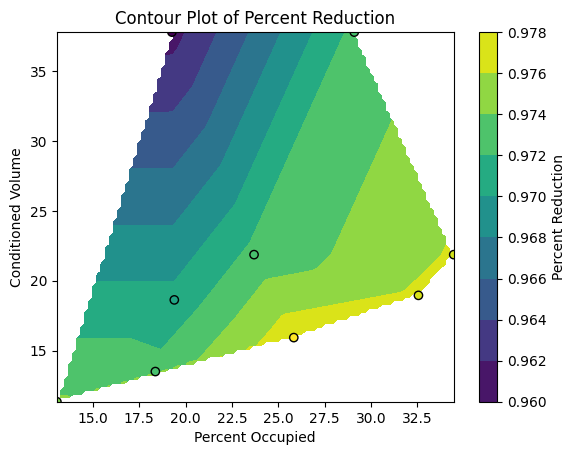

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

df = results

X = df['OccupancyPercentage']
Y = df['volume']
Z = df['percent_reduction']

x_min, x_max = X.min() , X.max()
y_min, y_max = Y.min() , Y.max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

Z_interp = griddata((X, Y), Z, (xx, yy), method='linear')

plt.contourf(xx, yy, Z_interp, cmap='viridis')
plt.colorbar(label='Percent Reduction')
plt.scatter(X, Y, c=Z, cmap='viridis', edgecolor='black')
plt.xlabel('Percent Occupied')
plt.ylabel('Conditioned Volume')
plt.title('Contour Plot of Percent Reduction')
plt.show()
